<a href="https://colab.research.google.com/github/ErisAlfionita8/anum-group-project/blob/main/eas_nilai_optimum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisis Optimasi Performa Akademik Siswa Menggunakan Metode Numerik: Pencarian Titik Maksimum dan Jalur Penurunan GPA**

#Anggota Kelompok


- Eris alfionita (24083010032)
- Alifah Zuhrah (24083010033)
- Elina Putri (24083010085)

#Data Info



## 📊 Tabel Skala Pengukuran Variabel

| Variabel          | Nama Kolom         | Skala Pengukuran   | Kode / Rentang                                                                                  |
| ----------------- | ------------------ | ------------------ | ----------------------------------------------------------------------------------------------- |
| StudentID         | student_id         | Nominal            | 1001 – 3392                                                                                     |
| Age               | age                | Rasio              | 15 – 18 tahun                                                                                   |
| Gender            | gender             | Nominal (Dikotomi) | 0 = Laki-laki<br>1 = Perempuan                                                                  |
| Ethnicity         | ethnicity          | Nominal            | 0 = Caucasian<br>1 = African American<br>2 = Asian<br>3 = Other                                 |
| ParentalEducation | parental_education | Ordinal            | 0 = Tidak sekolah<br>1 = SMA<br>2 = Some College<br>3 = Bachelor’s Degree<br>4 = Higher (S2/S3) |
| StudyTimeWeekly   | study_time_weekly  | Rasio              | 0 – 20 jam per minggu                                                                           |
| Absences          | absences           | Rasio              | 0 – 30 kali                                                                                     |
| Tutoring          | tutoring           | Nominal (Dikotomi) | 0 = Tidak<br>1 = Ya                                                                             |
| ParentalSupport   | parental_support   | Ordinal            | 0 = None<br>1 = Low<br>2 = Moderate<br>3 = High<br>4 = Very High                                |
| Extracurricular   | extracurricular    | Nominal (Dikotomi) | 0 = Tidak<br>1 = Ya                                                                             |
| Sports            | sports             | Nominal (Dikotomi) | 0 = Tidak<br>1 = Ya                                                                             |
| Music             | music              | Nominal (Dikotomi) | 0 = Tidak<br>1 = Ya                                                                             |
| Volunteering      | volunteering       | Nominal (Dikotomi) | 0 = Tidak<br>1 = Ya                                                                             |
| GPA               | gpa                | Interval           | 2.0 – 4.0                                                                                       |
| GradeClass        | grade_class        | Ordinal            | 0 = A (≥ 3.5)<br>1 = B (3.0–3.49)<br>2 = C (2.5–2.99)<br>3 = D (2.0–2.49)<br>4 = F (< 2.0)      |

---

### 📌 Catatan Akademik (opsional untuk skripsi)

* **Rasio** → memiliki nol absolut (Age, StudyTimeWeekly, Absences)
* **Interval** → jarak bermakna, nol tidak absolut (GPA)
* **Ordinal** → ada urutan, jarak tidak harus sama (ParentalEducation, ParentalSupport, GradeClass)
* **Nominal** → kategori tanpa urutan (Gender, Ethnicity, variabel dikotomi)



In [ ]:
!pip -q install kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

import kagglehub
path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
df = pd.read_csv(f'{path}/Student_performance_data _.csv')
print(df.head(3))
df.info()

Using Colab cache for faster access to the 'students-performance-dataset' dataset.


### 1. Penentuan Nilai Optimum Global GPA

In [ ]:
from scipy.optimize import minimize
def GPA_func(x):
    study, absences, parental, tutoring = x
    gpa = (
        2 +
        0.08 * study -
        0.1 * absences +
        0.3 * parental +
        0.25 * tutoring -
        0.002 * study**2
    )
    return -gpa

bounds = [
    (0, 20),    # StudyTimeWeekly
    (0, 15),    # Absences
    (0, 1),     # ParentalSupport
    (0, 1)      # Tutoring
]

In [ ]:
# ----- Menentukan titik maksimum global fungsi GPA pada domain variabel study_time_weekly, absences, parental_support, dan tutoring.
x0 = [10, 5, 0.5, 0.5]

# Optimasi
res = minimize(GPA_func, x0, bounds=bounds, method='L-BFGS-B')
max_point = res.x
max_gpa = -res.fun

print("Titik maksimum global:")
print(f"StudyTimeWeekly = {max_point[0]:.2f}")
print(f"Absences        = {max_point[1]:.2f}")
print(f"ParentalSupport = {max_point[2]:.2f}")
print(f"Tutoring        = {max_point[3]:.2f}")
print(f"GPA maksimum    = {max_gpa:.2f}")

Titik maksimum global:
StudyTimeWeekly = 20.00
Absences        = 0.00
ParentalSupport = 1.00
Tutoring        = 1.00
GPA maksimum    = 3.35


Titik maksimum global diperoleh pada kombinasi

 StudyTimeWeekly = 20 jam, Absences = 0, ParentalSupport = 1 (low), Tutoring = 1 (ya, mengikuti tutoring)

 Menghasilkan GPA maksimum sebesar 3,35.

 Nilai StudyTimeWeekly menunjukkan bahwa alokasi waktu belajar mingguan yang tinggi berkontribusi positif terhadap pencapaian akademik. Nilai Absences = 0 mengindikasikan bahwa kehadiran penuh mendukung optimalisasi prestasi belajar. Nilai ParentalSupport = 1 menunjukkan bahwa keberadaan dukungan orang tua, meskipun pada tingkat rendah, tetap berperan dalam peningkatan GPA. Sementara itu, nilai Tutoring = 1 menandakan bahwa partisipasi dalam bimbingan belajar turut membantu siswa mencapai performa akademik yang lebih baik. Berdasarkan hasil tersebut, nilai GPA 3,35 termasuk dalam rentang GradeClass B, sehingga kelas ini ditetapkan sebagai hasil optimum.

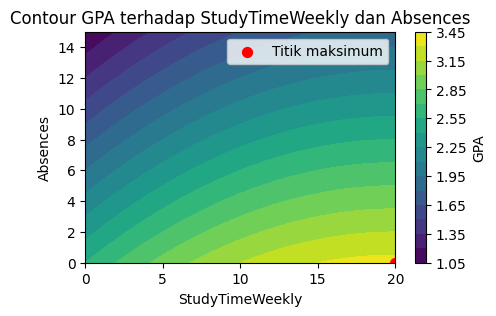

In [ ]:
parental_opt = max_point[2]
tutoring_opt = max_point[3]

study = np.linspace(0, 20, 100)
absences = np.linspace(0, 15, 100)
STUDY, ABS = np.meshgrid(study, absences)

GPA_grid = (
  2 +
  0.08 * STUDY -
  0.1 * ABS +
  0.3 * parental_opt +
  0.25 * tutoring_opt -
  0.002 * STUDY**2
)

plt.figure(figsize=(5,3))
cp = plt.contourf(STUDY, ABS, GPA_grid, levels=20, cmap='viridis')
plt.colorbar(cp, label='GPA')
plt.xlabel("StudyTimeWeekly")
plt.ylabel("Absences")
plt.title("Contour GPA terhadap StudyTimeWeekly dan Absences")

# titik maksimum
plt.scatter(max_point[0], max_point[1], color='r', s=50, label='Titik maksimum')
plt.legend()
plt.show()

Grafik contour GPA memperlihatkan pola yang konsisten dengan hasil optimasi sebelumnya, di mana nilai GPA meningkat seiring bertambahnya StudyTimeWeekly dan menurun ketika Absences meningkat.Titik merah pada grafik menandai titik maksimum, yang berada pada StudyTimeWeekly sekitar 20 jam dan Absences mendekati 0, yang sama dengan titik maksimum global yang menghasilkan GPA sebesar 3,35.

Hasil visualisasi ini memperkuat interpretasi bahwa alokasi waktu belajar yang tinggi dan kehadiran penuh merupakan faktor utama dalam mencapai kondisi akademik yang optimal. Temuan ini selaras dengan pembahasan sebelumnya, di mana kombinasi kedua variabel tersebut, bersama dengan ParentalSupport dan Tutoring, membentuk kondisi paling optimal yang mengarahkan siswa pada GradeClass B sebagai hasil optimum.

In [ ]:
# ----- Evaluasi apakah titik maksimum yang diperoleh merupakan maksimum lokal atau maksimum global dengan membandingkan beberapa titik awal pencarian.
np.random.seed(42)
initial_guesses = [np.random.uniform([0,0,0,0], [20,15,1,1]) for _ in range(10)]

results = []
for x0 in initial_guesses:
  res = minimize(GPA_func, x0, bounds=bounds, method='L-BFGS-B')
  results.append((-res.fun, res.x))
results.sort(reverse=True, key=lambda x: x[0])
print("Top 3 hasil optimasi dari beberapa titik awal:")
for i, (gpa, point) in enumerate(results[:3], 1):
  print(f"{i}. GPA = {gpa:.2f}, titik = {point}")

Top 3 hasil optimasi dari beberapa titik awal:
1. GPA = 3.35, titik = [20.  0.  1.  1.]
2. GPA = 3.35, titik = [20.  0.  1.  1.]
3. GPA = 3.35, titik = [20.  0.  1.  1.]


## 2. Simulasi Jalur Penurunan GPA

In [ ]:
# ----- Simulasi jalur penurunan GPA dari beberapa kondisi awal acak menuju titik minimum lokal.
def GPA_func(x, parental, tutoring):
    study, absences, age = x
    gpa = (
        2 +
        0.08 * study -
        0.1 * absences +
        0.3 * parental +
        0.25 * tutoring +
        0.02 * age -
        0.002 * study**2
    )
    return gpa

def grad_GPA_continuous(x, parental, tutoring, h=1e-5):
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x1 = x.copy()
        x2 = x.copy()
        x1[i] += h
        x2[i] -= h
        grad[i] = (GPA_func(x1, parental, tutoring) - GPA_func(x2, parental, tutoring)) / (2*h)
    return grad

alpha = 0.5  # learning rate
steps = 300

# Variabel diskrit (ParentalSupport, Tutoring)
diskrit_combos = [(0,0), (0,1), (1,0), (1,1)]

# Jumlah kondisi awal acak untuk tiap kombinasi diskrit
n_init = 3
np.random.seed(42)

In [ ]:
import plotly.graph_objects as go

colors = ['red', 'green', 'blue', 'magenta']

fig = go.Figure()

for idx, (parental, tutoring) in enumerate(diskrit_combos):
    # Titik awal acak: StudyTimeWeekly, Absences, Age
    initial_points = np.random.uniform([0,0,13], [20,15,18], (n_init, 3))

    for j, x0 in enumerate(initial_points):
        path = [x0.copy()]
        x = x0.copy()
        for _ in range(steps):
            grad = grad_GPA_continuous(x, parental, tutoring)
            x = x + alpha * grad  # naik gradien
            x[0] = np.clip(x[0], 0, 20)
            x[1] = np.clip(x[1], 0, 15)
            x[2] = np.clip(x[2], 13, 18)
            path.append(x.copy())
        path = np.array(path)
        gpa_path = np.array([GPA_func(p, parental, tutoring) for p in path])

        # Plot jalur 3D interaktif
        fig.add_trace(go.Scatter3d(
            x=path[:,0],        # StudyTimeWeekly
            y=path[:,1],        # Absences
            z=gpa_path,         # GPA
            mode='lines+markers',
            line=dict(color=colors[idx], width=4),
            marker=dict(size=3),
            name=f'PS={parental}, Tutoring={tutoring}' if j==0 else None,
            showlegend=(j==0)
        ))

fig.update_layout(
    title='Simulasi Jalur Gradient Descent dengan Age + Variabel Diskrit (Interaktif)',
    scene=dict(
        xaxis_title='StudyTimeWeekly',
        yaxis_title='Absences',
        zaxis_title='GPA'
    ),
    legend=dict(x=0, y=1)
)

fig.show()

- PS = ParentalSupport


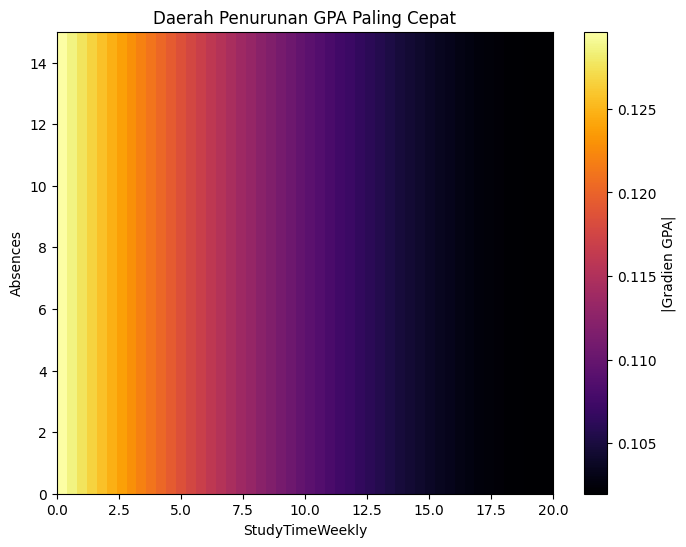

In [ ]:
# ----- Identifikasi daerah ruang variabel yang menghasilkan penurunan GPA paling cepat.

import numpy as np
import matplotlib.pyplot as plt

study_vals = np.linspace(0, 20, 50)
abs_vals = np.linspace(0, 15, 50)

STUDY, ABS = np.meshgrid(study_vals, abs_vals)
AGE_random = np.random.uniform(13, 18, size=STUDY.shape)

# Hitung gradien per titik
grad_norm = np.zeros_like(STUDY)
for i in range(STUDY.shape[0]):
    for j in range(STUDY.shape[1]):
        point = np.array([STUDY[i,j], ABS[i,j], AGE_random[i,j]])
        grad = grad_GPA_continuous(point, parental=1, tutoring=1)
        grad_norm[i,j] = np.linalg.norm(grad)

# Plot heatmap
plt.figure(figsize=(8,6))
plt.imshow(grad_norm, origin='lower', extent=[0,20,0,15],
           aspect='auto', cmap='inferno')
plt.colorbar(label='|Gradien GPA|')
plt.xlabel('StudyTimeWeekly')
plt.ylabel('Absences')
plt.title('Daerah Penurunan GPA Paling Cepat')
plt.show()


Contoh ambil pada titik StudyTimeWeekly = 15,0 dan Absences = 4

area pada grafik berada pada warna ungu gelap menuju hitam. Warna ini menunjukkan magnitudo gradien yang relatif kecil, yang berarti laju penurunan GPA tidak terlalu cepat dibandingkan area berwarna lebih terang di sisi kiri grafik.

Pada kondisi ini GPA masih mengalami penurunan jika terjadi perubahan, tetapi penurunannya berlangsung lebih lambat. Hal ini mengindikasikan bahwa dengan waktu belajar yang cukup tinggi (15 jam per minggu), dampak negatif dari absensi sebanyak 4 kali tidak langsung menyebabkan penurunan GPA yang drastis.

Namun demikian, titik ini belum berada pada kondisi optimal, karena masih terdapat absensi dan waktu belajar belum maksimum. Jika StudyTimeWeekly ditingkatkan dan Absences ditekan lebih rendah, posisi siswa akan bergerak mendekati titik optimum yang menghasilkan GPA maksimum.